# Training Deep Learning Models

In [15]:
# ===================================================
# Deep Neural Network with
# Adam + BatchNorm + Dropout
# + L1 + L2 + Early Stopping
# + He Initialization
# ===================================================
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    auc)

# ---------------------------------------------------
# 1. Create Sample Data
# ---------------------------------------------------

np.random.seed(42)
torch.manual_seed(42)

n = 2000

x1 = np.random.normal(size=n)
x2 = np.random.normal(size=n)

logit = 2 * x1 - 1.5 * x2
prob = 1 / (1 + np.exp(-logit))

y = np.random.binomial(1, prob)

X = np.column_stack([x1, x2])

# ---------------------------------------------------
# 2. Split Data
# ---------------------------------------------------
XTrain, X_temp, YTrain, Y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42)

XTest, XValid, YTest, YValid = train_test_split(
    X_temp,
    Y_temp,
    test_size=0.50,
    random_state=42)

In [17]:
# ---------------------------------------------------
# 3. Convert to PyTorch Tensors
# ---------------------------------------------------
XTrain_t = torch.FloatTensor(XTrain)
XTest_t = torch.FloatTensor(XTest)
XValid_t = torch.FloatTensor(XValid)

YTrain_t = torch.FloatTensor(YTrain).reshape(-1, 1)
YTest_t = torch.FloatTensor(YTest).reshape(-1, 1)
YValid_t = torch.FloatTensor(YValid).reshape(-1, 1)

In [18]:
# ---------------------------------------------------
# 4. Define Model
# ---------------------------------------------------
model = nn.Sequential(

    nn.Linear(XTrain_t.shape[1], 8),
    nn.BatchNorm1d(8),
    nn.ReLU(),
    nn.Dropout(0.30),

    nn.Linear(8, 4),
    nn.BatchNorm1d(4),
    nn.ReLU(),
    nn.Dropout(0.30),

    nn.Linear(4, 1),
    nn.Sigmoid()
)

In [19]:
# ---------------------------------------------------
# 5. He Initialization
# ---------------------------------------------------
for layer in model:

    if isinstance(layer, nn.Linear):

        nn.init.kaiming_uniform_(
            layer.weight,
            nonlinearity='relu')
        nn.init.zeros_(layer.bias)

# ---------------------------------------------------
# 6. Loss Function and Optimizer
# ---------------------------------------------------

criterion = nn.BCELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.01,
    weight_decay=1e-4  )    # L2 Regularization

# L1 Regularization Strength

l1_lambda = 1e-5

# ---------------------------------------------------
# 7. Training Loop with Early Stopping
# ---------------------------------------------------

epochs = 20
batch_size = 32

loss_history = []
val_loss_history = []

best_val_loss = np.inf
patience = 15
counter = 0

for epoch in range(epochs):

    model.train()

    for i in range(0, len(XTrain_t), batch_size):

        X_batch = XTrain_t[i:i + batch_size]
        Y_batch = YTrain_t[i:i + batch_size]

        # Forward Pass

        y_hat = model(X_batch)

        loss = criterion(
            y_hat,
            Y_batch
        )

        # L1 Regularization

        l1_norm = sum(
            p.abs().sum()
            for p in model.parameters()
        )

        loss = loss + l1_lambda * l1_norm

        # Backpropagation

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

    loss_history.append(loss.item())

    # -----------------------------------
    # Validation Loss
    # -----------------------------------

    model.eval()

    with torch.no_grad():

        val_pred = model(XValid_t)

        val_loss = criterion(
            val_pred,
            YValid_t
        )

    val_loss_history.append(
        val_loss.item()
    )

    # -----------------------------------
    # Early Stopping
    # -----------------------------------

    if val_loss.item() < best_val_loss:

        best_val_loss = val_loss.item()

        best_model_state = {
            key: value.clone()
            for key, value
            in model.state_dict().items()
        }

        counter = 0

    else:

        counter += 1

    if epoch % 50 == 0:

        print(
            f"Epoch {epoch:3d} | "
            f"Train Loss = {loss.item():.4f} | "
            f"Validation Loss = {val_loss.item():.4f}"
        )

    if counter >= patience:

        print(
            f"\nEarly stopping triggered "
            f"at epoch {epoch}"
        )

        break

# Restore Best Model

model.load_state_dict(
    best_model_state)

Epoch   0 | Train Loss = 0.5769 | Validation Loss = 0.5774


<All keys matched successfully>


Accuracy
Train      : 0.801
Test       : 0.820
Validation : 0.833

Confusion Matrix
[[123  23]
 [ 27 127]]

ROC-AUC = 0.890


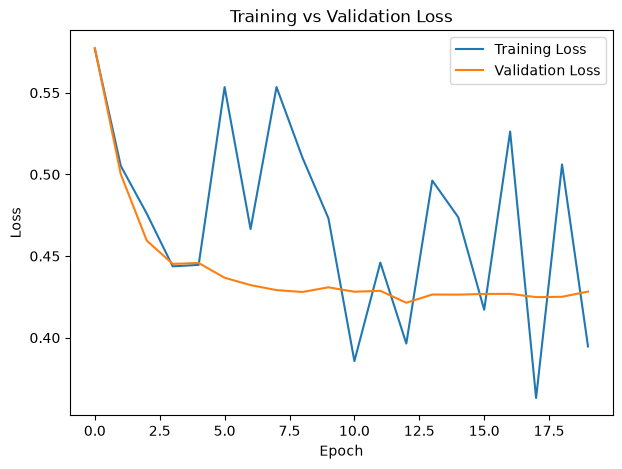

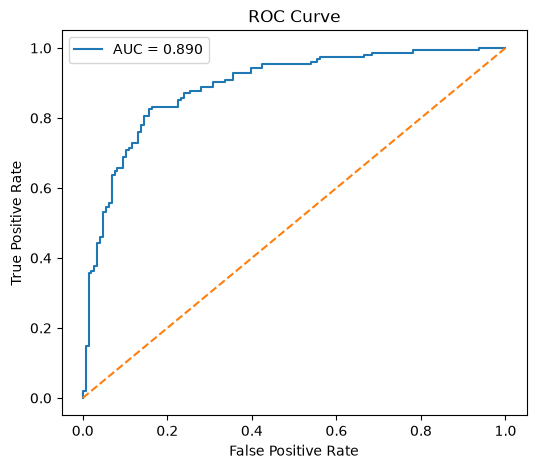

In [20]:
# ---------------------------------------------------
# 8. Evaluation
# ---------------------------------------------------

model.eval()

with torch.no_grad():

    Train_prob = model(XTrain_t).numpy().flatten()
    Test_prob = model(XTest_t).numpy().flatten()
    Valid_prob = model(XValid_t).numpy().flatten()

Train_pred = (Train_prob >= 0.5).astype(int)
Test_pred = (Test_prob >= 0.5).astype(int)
Valid_pred = (Valid_prob >= 0.5).astype(int)

# ---------------------------------------------------
# 9. Accuracy
# ---------------------------------------------------
Train_acc = np.mean(YTrain == Train_pred)
Test_acc = np.mean(YTest == Test_pred)
Valid_acc = np.mean(YValid == Valid_pred)
print("\nAccuracy")
print(f"Train      : {Train_acc:.3f}")
print(f"Test       : {Test_acc:.3f}")
print(f"Validation : {Valid_acc:.3f}")

# ---------------------------------------------------
# 10. Confusion Matrix
# ---------------------------------------------------
CM = confusion_matrix(
    YValid,
    Valid_pred)
print("\nConfusion Matrix")
print(CM)

# ---------------------------------------------------
# 11. ROC-AUC
# ---------------------------------------------------
FPR, TPR, thresholds = roc_curve(
    YValid,
    Valid_prob)

ROC_AUC = auc(
    FPR,
    TPR)

print(f"\nROC-AUC = {ROC_AUC:.3f}")

# ---------------------------------------------------
# 12. Training vs Validation Loss
# ---------------------------------------------------
plt.figure(figsize=(7, 5))
plt.plot(loss_history,label="Training Loss")
plt.plot(val_loss_history,label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

# ---------------------------------------------------
# 13. ROC Curve
# ---------------------------------------------------
plt.figure(figsize=(6, 5))
plt.plot(
    FPR,
    TPR,
    label=f"AUC = {ROC_AUC:.3f}")

plt.plot(
    [0, 1],
    [0, 1],
    "--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()